In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

print("PyTorch:", torch.__version__)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", device)

PyTorch: 2.11.0+cpu
Dispositivo: cpu


In [5]:
ruta = '/content/drive/MyDrive/Colab Notebooks/Machine Learning Soto/Datasets/Lab01/auto_mpg_peso_mpg.csv'

data = pd.read_csv(ruta)

data.head()

,weight,mpg
0,3504.0,18.0
1,3693.0,15.0
2,3436.0,18.0
3,3433.0,16.0
4,3449.0,17.0


In [6]:
data = data[['weight', 'mpg']].copy()

X = data[['weight']].values.astype(np.float32)
y = data[['mpg']].values.astype(np.float32)

print("Dimensión X:", X.shape)
print("Dimensión y:", y.shape)
print("Cantidad de ejemplos:", len(X))

Dimensión X: (398, 1)
Dimensión y: (398, 1)
Cantidad de ejemplos: 398


In [7]:
np.random.seed(42)

indices = np.random.permutation(len(X))

train_size = int(len(X) * 0.80)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

X_train = X[train_indices]
y_train = y[train_indices]

X_val = X[val_indices]
y_val = y[val_indices]

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)

Entrenamiento: (318, 1) (318, 1)
Validación: (80, 1) (80, 1)


In [8]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)

X_train_norm = (X_train - mu) / sigma
X_val_norm = (X_val - mu) / sigma

print("Media:", mu)
print("Desviación:", sigma)

print("\nMedia después de normalizar:")
print(X_train_norm.mean(axis=0))

print("\nDesviación después de normalizar:")
print(X_train_norm.std(axis=0))

Media: [2983.5913]
Desviación: [859.1845]

Media después de normalizar:
[-1.379529e-07]

Desviación después de normalizar:
[1.]


In [9]:
class DatasetPersonalizado(torch.utils.data.Dataset):

    def __init__(self, X, Y):

        self.X = torch.from_numpy(X).float()
        self.Y = torch.from_numpy(Y).float()


    def __len__(self):

        return len(self.X)


    def __getitem__(self, ix):

        return self.X[ix], self.Y[ix]

In [10]:
dataset = {
    'train': DatasetPersonalizado(
        X_train_norm,
        y_train
    ),

    'val': DatasetPersonalizado(
        X_val_norm,
        y_val
    )
}

print("Train:", len(dataset['train']))
print("Validación:", len(dataset['val']))

Train: 318
Validación: 80


In [11]:
dataloader = {

    'train': torch.utils.data.DataLoader(
        dataset['train'],
        batch_size=32,
        shuffle=True
    ),

    'val': torch.utils.data.DataLoader(
        dataset['val'],
        batch_size=32,
        shuffle=False
    )
}

In [12]:
x_b, y_b = next(iter(dataloader['train']))

print("X batch:", x_b.shape)
print("y batch:", y_b.shape)

X batch: torch.Size([32, 1])
y batch: torch.Size([32, 1])


In [13]:
class ModeloRegresionLineal(torch.nn.Module):

    def __init__(self):

        super(ModeloRegresionLineal, self).__init__()

        self.linear = torch.nn.Linear(
            1,
            1
        )


    def forward(self, x):

        return self.linear(x)

In [14]:
model = ModeloRegresionLineal().to(device)

model

ModeloRegresionLineal(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

In [15]:
criterion = torch.nn.MSELoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)

In [16]:
def fit(
    model,
    dataloader,
    optimizer,
    epochs=300,
    log_each=50
):

    criterion = torch.nn.MSELoss()

    train_loss = []
    val_loss = []

    best_loss = float('inf')


    for e in range(1, epochs + 1):

        # =========================
        # ENTRENAMIENTO
        # =========================

        model.train()

        _train_loss = []


        for x_b, y_b in dataloader['train']:

            x_b = x_b.to(device)
            y_b = y_b.to(device)

            # forward
            y_pred = model(x_b)

            # loss
            loss = criterion(
                y_pred,
                y_b
            )

            _train_loss.append(
                loss.item()
            )

            # poner gradientes a cero
            optimizer.zero_grad()

            # backpropagation
            loss.backward()

            # actualizar pesos
            optimizer.step()


        train_loss.append(
            np.mean(_train_loss)
        )


        # =========================
        # VALIDACIÓN
        # =========================

        model.eval()

        _val_loss = []


        with torch.no_grad():

            for x_b, y_b in dataloader['val']:

                x_b = x_b.to(device)
                y_b = y_b.to(device)

                y_pred = model(x_b)

                loss = criterion(
                    y_pred,
                    y_b
                )

                _val_loss.append(
                    loss.item()
                )


        val_loss.append(
            np.mean(_val_loss)
        )


        # guardar mejor modelo
        if val_loss[-1] < best_loss:

            best_loss = val_loss[-1]

            torch.save(
                model.state_dict(),
                'mejor_modelo_lab01.pt'
            )


        if not e % log_each:

            print(
                f"Epoch {e}/{epochs} "
                f"loss {train_loss[-1]:.5f} "
                f"val_loss {val_loss[-1]:.5f}"
            )


    # cargar mejor modelo obtenido
    model.load_state_dict(
        torch.load(
            'mejor_modelo_lab01.pt',
            map_location=device
        )
    )


    return {
        'epoch':
            list(range(1, len(train_loss) + 1)),

        'loss':
            train_loss,

        'val_loss':
            val_loss
    }

In [17]:
model = ModeloRegresionLineal().to(device)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)

hist = fit(
    model,
    dataloader,
    optimizer,
    epochs=300,
    log_each=50
)

Epoch 50/300 loss 18.89730 val_loss 20.09247
Epoch 100/300 loss 18.80438 val_loss 20.08971
Epoch 150/300 loss 18.89956 val_loss 20.08754
Epoch 200/300 loss 18.81462 val_loss 20.09660
Epoch 250/300 loss 18.93734 val_loss 20.08713
Epoch 300/300 loss 18.83587 val_loss 20.09015


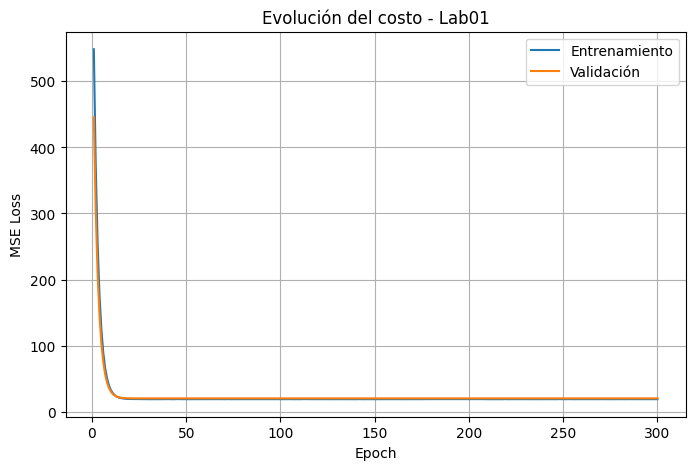

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    hist['epoch'],
    hist['loss'],
    label='Entrenamiento'
)

plt.plot(
    hist['epoch'],
    hist['val_loss'],
    label='Validación'
)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')

plt.title(
    'Evolución del costo - Lab01'
)

plt.legend()
plt.grid()

plt.show()

In [19]:
model.eval()

predicciones = []
valores_reales = []


with torch.no_grad():

    for x_b, y_b in dataloader['val']:

        x_b = x_b.to(device)

        y_pred = model(x_b)

        predicciones.extend(
            y_pred.cpu().numpy()
        )

        valores_reales.extend(
            y_b.numpy()
        )


y_pred = np.array(predicciones).flatten()
y_real = np.array(valores_reales).flatten()

In [20]:
mse = mean_squared_error(
    y_real,
    y_pred
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    y_real,
    y_pred
)

r2 = r2_score(
    y_real,
    y_pred
)


print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 18.575830459594727
RMSE: 4.3099687306980226
MAE : 3.383759021759033
R²  : 0.6838868856430054


In [21]:
print(
    "w:",
    model.linear.weight.item()
)

print(
    "b:",
    model.linear.bias.item()
)

w: -6.4860076904296875
b: 23.266185760498047


In [22]:
X_nuevos = np.array([
    [1750],
    [2250],
    [2750],
    [3000],
    [3500],
    [3750],
    [4000],
    [4250],
    [4500],
    [4750]
], dtype=np.float32)

In [23]:
X_nuevos_norm = (
    X_nuevos - mu
) / sigma

In [24]:
X_nuevos_t = torch.from_numpy(
    X_nuevos_norm
).float().to(device)

In [25]:
model.eval()

with torch.no_grad():

    pred_nuevos = model(
        X_nuevos_t
    )

In [26]:
for peso, pred in zip(
    X_nuevos,
    pred_nuevos
):

    print(
        f"Peso: {peso[0]:.0f} lb "
        f"→ MPG predicho: "
        f"{pred.item():.2f}"
    )

Peso: 1750 lb → MPG predicho: 32.58
Peso: 2250 lb → MPG predicho: 28.80
Peso: 2750 lb → MPG predicho: 25.03
Peso: 3000 lb → MPG predicho: 23.14
Peso: 3500 lb → MPG predicho: 19.37
Peso: 3750 lb → MPG predicho: 17.48
Peso: 4000 lb → MPG predicho: 15.59
Peso: 4250 lb → MPG predicho: 13.71
Peso: 4500 lb → MPG predicho: 11.82
Peso: 4750 lb → MPG predicho: 9.93


In [30]:
PATH = (
    '/content/drive/MyDrive/'
    'Colab Notebooks/'
    'Machine Learning Soto/'
    'LabPyTorch/'
    'lab01_checkpoint.pt'
)

In [32]:
import os

carpeta = '/content/drive/MyDrive/Colab Notebooks/Machine Learning Soto/LabPyTorch'

os.makedirs(carpeta, exist_ok=True)

PATH = carpeta + '/lab01_checkpoint.pt'

print("Carpeta existe:", os.path.exists(carpeta))
print("Ruta:", PATH)

Carpeta existe: True
Ruta: /content/drive/MyDrive/Colab Notebooks/Machine Learning Soto/LabPyTorch/lab01_checkpoint.pt


In [33]:
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),

        'mu': mu,
        'sigma': sigma,

        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    },
    PATH
)

print("Modelo guardado correctamente")

Modelo guardado correctamente


In [34]:
print(os.path.exists(PATH))

True


In [35]:
checkpoint = torch.load(
    PATH,
    map_location=device,
    weights_only=False
)

print("Checkpoint cargado")

Checkpoint cargado


In [36]:
modelo_cargado = ModeloRegresionLineal().to(device)

modelo_cargado.load_state_dict(
    checkpoint['model_state_dict']
)

modelo_cargado.eval()

print("Modelo recuperado correctamente")

Modelo recuperado correctamente


In [37]:
mu_cargada = checkpoint['mu']
sigma_cargada = checkpoint['sigma']

print("Media:", mu_cargada)
print("Desviación:", sigma_cargada)

Media: [2983.5913]
Desviación: [859.1845]


In [38]:
print("MSE :", checkpoint['mse'])
print("RMSE:", checkpoint['rmse'])
print("MAE :", checkpoint['mae'])
print("R²  :", checkpoint['r2'])

MSE : 18.575830459594727
RMSE: 4.3099687306980226
MAE : 3.383759021759033
R²  : 0.6838868856430054


In [39]:
peso_prueba = np.array(
    [[3000]],
    dtype=np.float32
)

peso_prueba_norm = (
    peso_prueba - mu_cargada
) / sigma_cargada

peso_tensor = torch.from_numpy(
    peso_prueba_norm
).float().to(device)

modelo_cargado.eval()

with torch.no_grad():

    prediccion = modelo_cargado(
        peso_tensor
    )

print(
    "Peso: 3000 lb"
)

print(
    "MPG predicho:",
    prediccion.item()
)

Peso: 3000 lb
MPG predicho: 23.142316818237305


In [40]:
print("LABORATORIO 01 PYTORCH COMPLETADO")
print("Dataset      : Auto MPG")
print("Entrada      : weight")
print("Salida       : mpg")
print("Modelo       : Regresión lineal")
print("Dataset      : OK")
print("DataLoader   : OK")
print("MSELoss      : OK")
print("SGD          : OK")
print("Métricas     : OK")
print("Inferencias  : OK")
print("Checkpoint   : OK")

LABORATORIO 01 PYTORCH COMPLETADO
Dataset      : Auto MPG
Entrada      : weight
Salida       : mpg
Modelo       : Regresión lineal
Dataset      : OK
DataLoader   : OK
MSELoss      : OK
SGD          : OK
Métricas     : OK
Inferencias  : OK
Checkpoint   : OK
